Celda 1: Imports y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

os.makedirs('../figures', exist_ok=True)

print("✅ Librerías cargadas y configuración lista")

✅ Librerías cargadas y configuración lista


Celda 2: Carga del Dataset Final

In [2]:
# Cargar el dataset final: solo VENTAS de ARGENTINA
ruta_dataset = r'../data/processed/PROPERATI_VENTAS_ARG_FINAL.csv'

df = pd.read_csv(ruta_dataset, sep=';', decimal=',')

print("="*60)
print(" DATASET CARGADO: Ventas Inmobiliarias Argentina")
print("="*60)
print(f"Filas: {len(df):,}")
print(f"Columnas: {len(df.columns)}")
print(f"\nColumnas disponibles:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")

# Verificar que solo hay ventas
print(f"\n✅ Tipos de operación: {df['Operacion'].unique()}")

 DATASET CARGADO: Ventas Inmobiliarias Argentina
Filas: 447,347
Columnas: 12

Columnas disponibles:
  1. provincia
  2. ciudad
  3. Barrio
  4. Tipo Propiedad
  5. rooms
  6. Superficie Total
  7. Precio USD
  8. Precio m2
  9. Dias Mercado
  10. lat
  11. lon
  12. Operacion

✅ Tipos de operación: <StringArray>
['Venta']
Length: 1, dtype: str


Celda 3: KPIs Oficiales

In [3]:
print("="*60)
print(" KPIS OFICIALES - MERCADO DE VENTAS ARGENTINA")
print("="*60)

# Filtrar datos válidos para cálculos
df_validos = df[
    (df['Precio m2'].notna()) & 
    (df['Precio m2'] > 0) & 
    (df['Precio m2'] < 10000)
].copy()

kpi_total = len(df)
kpi_precio_mediano = df['Precio USD'].median()
kpi_precio_m2_promedio = df_validos['Precio m2'].mean()
kpi_precio_m2_mediano = df_validos['Precio m2'].median()
kpi_superficie_mediana = df['Superficie Total'].median()
kpi_dom_mediano = df['Dias Mercado'].median()

print(f"Total propiedades en venta: {kpi_total:,}")
print(f"Precio mediano: ${kpi_precio_mediano:,.0f} USD")
print(f"Precio/m² promedio: ${kpi_precio_m2_promedio:,.0f} USD")
print(f"Precio/m² mediano: ${kpi_precio_m2_mediano:,.0f} USD")
print(f"Superficie mediana: {kpi_superficie_mediana:.0f} m²")
print(f"Días en mercado (mediana): {kpi_dom_mediano:.0f} días")

 KPIS OFICIALES - MERCADO DE VENTAS ARGENTINA
Total propiedades en venta: 447,347
Precio mediano: $125,000 USD
Precio/m² promedio: $1,852 USD
Precio/m² mediano: $1,795 USD
Superficie mediana: 95 m²
Días en mercado (mediana): 15 días


Celda 4: Análisis por Provincia - Tabla KPIs

In [4]:
print("="*60)
print("🗺️ ANÁLISIS GEOGRÁFICO POR PROVINCIA")
print("="*60)

# Preparar datos geográficos válidos
geo_df = df[
    (df['provincia'].notna()) & 
    (df['Precio m2'].notna()) & 
    (df['Precio m2'] > 0) & 
    (df['Precio m2'] < 10000)
].copy()

# Calcular KPIs por provincia
kpi_provincia = geo_df.groupby('provincia').agg(
    total_ventas=('Tipo Propiedad', 'count'),
    precio_mediano=('Precio USD', 'median'),
    precio_m2_mediano=('Precio m2', 'median'),
    dias_mercado_mediano=('Dias Mercado', 'median'),
    superficie_mediana=('Superficie Total', 'median')
).sort_values('total_ventas', ascending=False)

# Mostrar tabla formateada (SIN .to_html() al final)
print("\n📋 TOP 10 PROVINCIAS POR VOLUMEN DE VENTAS:")
print("="*80)

kpi_provincia.head(10).style.format({
    'total_ventas': '{:,.0f}',
    'precio_mediano': '${:,.0f}',
    'precio_m2_mediano': '${:,.2f}',
    'dias_mercado_mediano': '{:.0f} días',
    'superficie_mediana': '{:.0f} m²'
})

🗺️ ANÁLISIS GEOGRÁFICO POR PROVINCIA

📋 TOP 10 PROVINCIAS POR VOLUMEN DE VENTAS:


,total_ventas,precio_mediano,precio_m2_mediano,dias_mercado_mediano,superficie_mediana
provincia,,,,,
Capital Federal,"87,086","$173,000","$2,475.00",15 días,71 m²
Bs.As. G.B.A. Zona Norte,"35,312","$225,000","$1,333.33",28 días,222 m²
Santa Fe,"18,481","$85,000","$1,486.49",29 días,75 m²
Bs.As. G.B.A. Zona Sur,"13,916","$110,000",$935.22,39 días,176 m²
Bs.As. G.B.A. Zona Oeste,"10,529","$110,000","$1,000.00",57 días,140 m²
Buenos Aires Costa Atlántica,"7,793","$85,000","$1,428.57",40 días,74 m²
Córdoba,"6,419","$86,000",$514.29,40 días,240 m²
Buenos Aires Interior,"2,793","$90,000",$182.50,30 días,528 m²
Neuquén,"2,296","$99,900",$467.89,42 días,297 m²


Celda 5: Visualización Dual-Axis (Volumen vs Precio/m²)

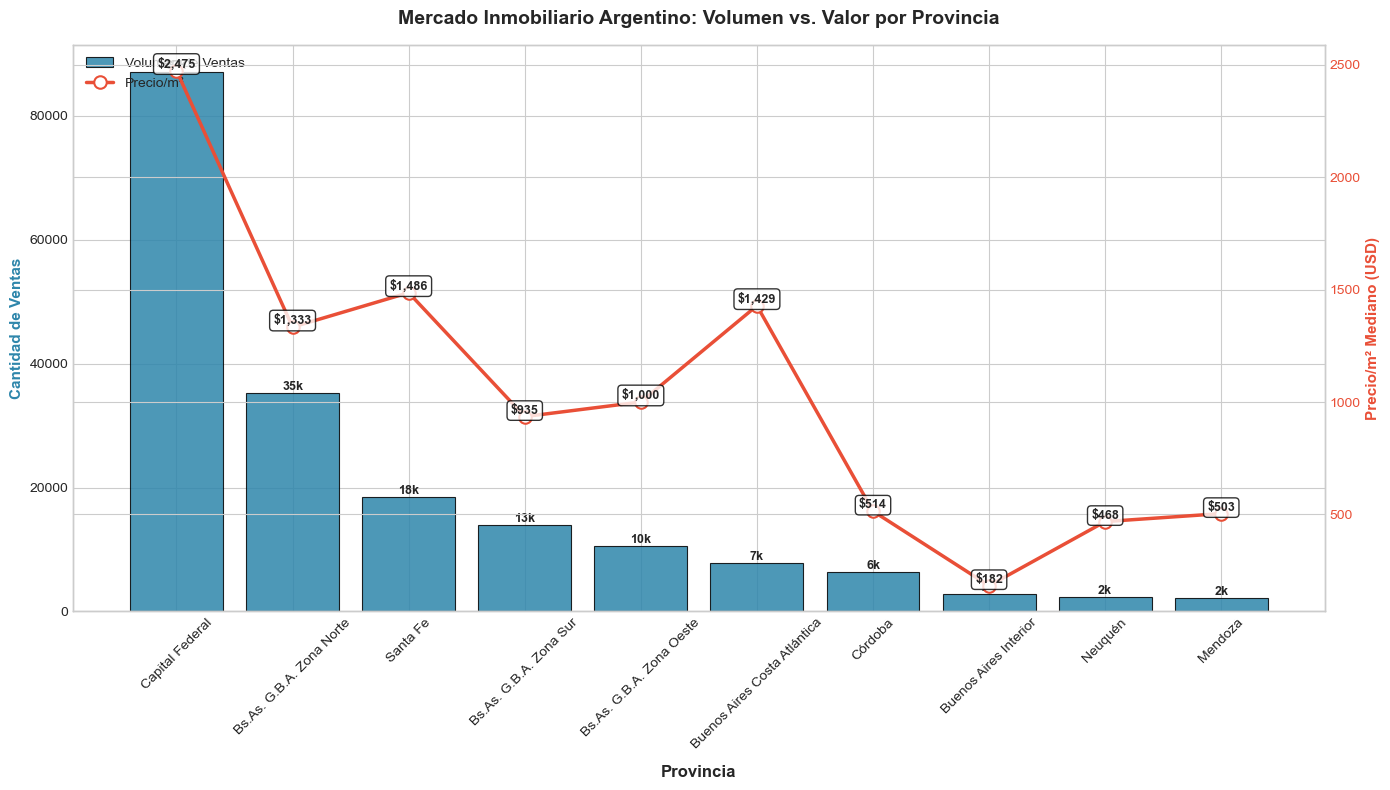

✅ Gráfico guardado: ../figures/01_volumen_vs_precio_provincia.png


<Figure size 640x480 with 0 Axes>

In [5]:
# Gráfico de barras + línea
fig, ax1 = plt.subplots(figsize=(14, 8))

top_10 = kpi_provincia.head(10)

# Barras: Volumen
color1 = '#2E86AB'
bars = ax1.bar(top_10.index, top_10['total_ventas'], 
        color=color1, alpha=0.85, label='Volumen de Ventas', 
        edgecolor='black', linewidth=0.8)

ax1.set_xlabel('Provincia', fontsize=12, fontweight='bold', labelpad=10)
ax1.set_ylabel('Cantidad de Ventas', color=color1, fontsize=11, fontweight='bold')
ax1.tick_params(axis='x', rotation=45, labelsize=10)
ax1.set_title('Mercado Inmobiliario Argentino: Volumen vs. Valor por Provincia', 
             fontsize=14, fontweight='bold', pad=15)

# Línea: Precio/m² (eje secundario)
ax2 = ax1.twinx()
color2 = '#E94F37'
ax2.plot(top_10.index, top_10['precio_m2_mediano'], 
         color=color2, marker='o', markersize=9, linewidth=2.5, 
         label='Precio/m²', markerfacecolor='white', markeredgewidth=1.5)

ax2.set_ylabel('Precio/m² Mediano (USD)', color=color2, fontsize=11, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color2, labelsize=10)

# Anotaciones en la línea
for i, (prov, row) in enumerate(top_10.iterrows()):
    ax2.annotate(f"${row['precio_m2_mediano']:,.0f}", 
                (i, row['precio_m2_mediano']),
                ha='center', va='bottom', fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# Anotaciones en las barras
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height/1000)}k',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Leyenda
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

# Guardar figura
plt.savefig('../figures/01_volumen_vs_precio_provincia.png', dpi=300, bbox_inches='tight')
print("✅ Gráfico guardado: ../figures/01_volumen_vs_precio_provincia.png")

Celda 6: Análisis de Barrios CABA

🏙️ ANÁLISIS DE BARRIOS - CAPITAL FEDERAL
Barrios analizados: 60


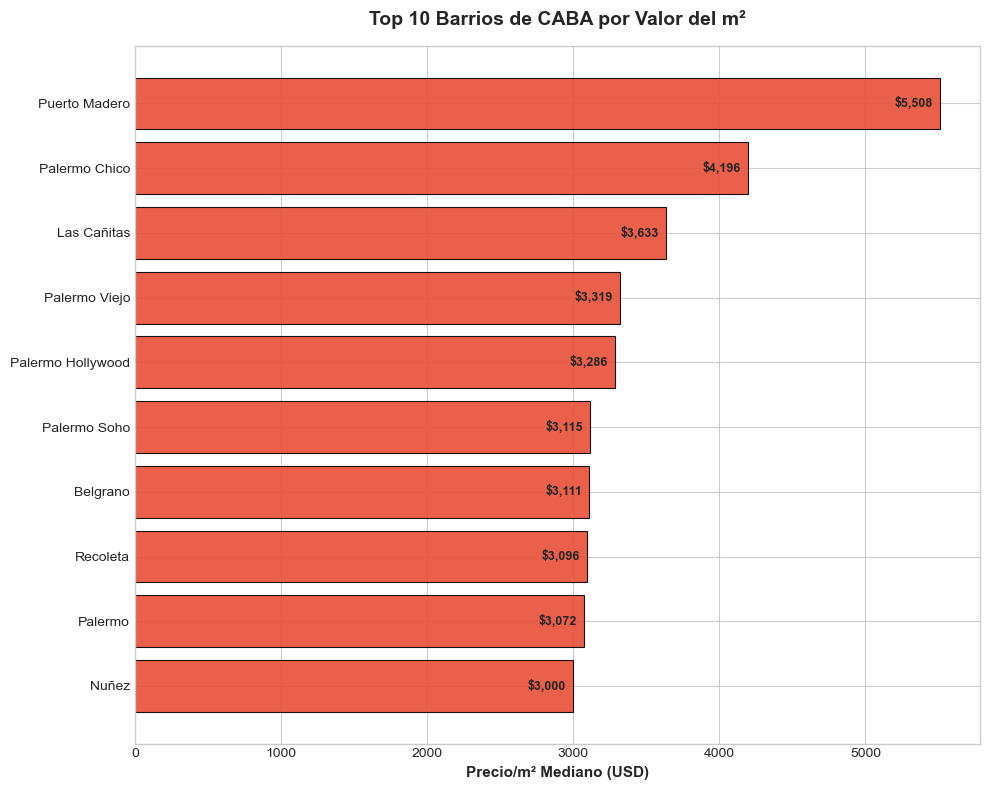

✅ Gráfico guardado: ../figures/02_caba_top10_barrios.png

📋 TOP 10 BARRIOS CABA POR PRECIO/M²:
     barrio_final  ventas  precio_m2  dom_mediano
    Puerto Madero    1378   5508.470         20.0
    Palermo Chico     885   4196.430         13.0
      Las Cañitas     652   3632.995         16.0
    Palermo Viejo     150   3319.440         15.0
Palermo Hollywood    1455   3285.570         15.0
     Palermo Soho    1342   3114.750         13.0
         Belgrano    7921   3111.110         26.0
         Recoleta    5665   3095.815         16.0
          Palermo   12148   3072.290         15.0
            Nuñez    2186   3000.000         35.5


<Figure size 640x480 with 0 Axes>

In [6]:
print("="*60)
print("🏙️ ANÁLISIS DE BARRIOS - CAPITAL FEDERAL")
print("="*60)

# Filtrar CABA y unificar barrios (l3 + l4)
caba_df = df[df['provincia'] == 'Capital Federal'].copy()

# Unificar barrio: usar Barrio (que ya es l4 o l3 unificado)
caba_df['barrio_final'] = caba_df['Barrio'].fillna(caba_df['ciudad'])

# Calcular métricas por barrio
barrio_stats = caba_df.groupby('barrio_final').agg(
    ventas=('Tipo Propiedad', 'count'),
    precio_m2=('Precio m2', 'median'),
    precio_total=('Precio USD', 'median'),
    dom_mediano=('Dias Mercado', 'median')
).reset_index()

# Filtros de calidad
barrio_stats = barrio_stats[
    (barrio_stats['ventas'] >= 20) &
    (barrio_stats['precio_m2'] > 500) &
    (barrio_stats['precio_m2'] < 10000)
].copy()

print(f"Barrios analizados: {len(barrio_stats)}")

# Top 10 por precio/m²
top_10_barrios = barrio_stats.sort_values('precio_m2', ascending=False).head(10)

# Visualización
fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(
    top_10_barrios['barrio_final'], top_10_barrios['precio_m2'],
    color='#E94F37', edgecolor='black', linewidth=0.8, alpha=0.9
)

ax.set_xlabel('Precio/m² Mediano (USD)', fontsize=11, fontweight='bold')
ax.set_title('Top 10 Barrios de CABA por Valor del m²', fontsize=14, fontweight='bold', pad=15)
ax.invert_yaxis()

# Anotaciones
for i, row in top_10_barrios.iterrows():
    ax.annotate(f"${row['precio_m2']:,.0f}", 
                (row['precio_m2'], row['barrio_final']),
                ha='right', va='center', fontsize=9, fontweight='bold',
                xytext=(-5, 0), textcoords='offset points')

plt.tight_layout()
plt.show()

plt.savefig('../figures/02_caba_top10_barrios.png', dpi=300, bbox_inches='tight')
print("✅ Gráfico guardado: ../figures/02_caba_top10_barrios.png")

# Tabla resumen
print("\n📋 TOP 10 BARRIOS CABA POR PRECIO/M²:")
print(top_10_barrios[['barrio_final', 'ventas', 'precio_m2', 'dom_mediano']].to_string(index=False))

Celda 7: Insights Accionables

In [7]:
print("="*60)
print("🎯 INSIGHTS ACCIONABLES - ESTRATEGIA DE VENTAS")
print("="*60)

# Líneas base
mediana_precio_m2 = barrio_stats['precio_m2'].median()
mediana_volumen = barrio_stats['ventas'].median()

print(f"\n📊 Benchmark CABA:")
print(f"   Precio/m² mediano: ${mediana_precio_m2:,.0f}")
print(f"   Ventas medianas por barrio: {mediana_volumen:.0f}")
print("-"*60)

# Segmento PREMIUM
premium = barrio_stats[
    (barrio_stats['precio_m2'] > mediana_precio_m2 * 1.2) &
    (barrio_stats['ventas'] >= mediana_volumen)
].sort_values('precio_m2', ascending=False)

print("\n💎 SECTOR PREMIUM (Alto valor + Liquidez):")
if len(premium) > 0:
    for _, row in premium.head(5).iterrows():
        print(f"   {row['barrio_final']}: ${row['precio_m2']:,.0f}/m² | "
              f"{row['ventas']:.0f} ventas | {row['dom_mediano']:.0f} días")
else:
    print("   (No hay barrios que cumplan ambos criterios estrictos)")

# Segmento OPORTUNIDAD
oportunidad = barrio_stats[
    (barrio_stats['precio_m2'] < mediana_precio_m2 * 0.9) &
    (barrio_stats['ventas'] > mediana_volumen * 1.2)
].sort_values('ventas', ascending=False)

print("\n SECTOR OPORTUNIDAD (Alta liquidez + Precio accesible):")
if len(oportunidad) > 0:
    for _, row in oportunidad.head(5).iterrows():
        descuento = (1 - row['precio_m2']/mediana_precio_m2) * 100
        print(f"   {row['barrio_final']}: ${row['precio_m2']:,.0f}/m² "
              f"({descuento:.0f}% bajo promedio) | {row['ventas']:.0f} ventas")
else:
    print("   (No se detectaron zonas con este perfil)")

print("\n" + "="*60)
print("💡 RECOMENDACIÓN ESTRATÉGICA:")
print("   1. Enfocar 70% del presupuesto de marketing en zonas Premium")
print("   2. Crear campañas de 'Oportunidad' en barrios de alta rotación")
print("   3. Revisar pricing en barrios con DOM > 1.5x mediana")

🎯 INSIGHTS ACCIONABLES - ESTRATEGIA DE VENTAS

📊 Benchmark CABA:
   Precio/m² mediano: $1,983
   Ventas medianas por barrio: 1089
------------------------------------------------------------

💎 SECTOR PREMIUM (Alto valor + Liquidez):
   Puerto Madero: $5,508/m² | 1378 ventas | 20 días
   Palermo Hollywood: $3,286/m² | 1455 ventas | 15 días
   Palermo Soho: $3,115/m² | 1342 ventas | 13 días
   Belgrano: $3,111/m² | 7921 ventas | 26 días
   Recoleta: $3,096/m² | 5665 ventas | 16 días

 SECTOR OPORTUNIDAD (Alta liquidez + Precio accesible):
   (No se detectaron zonas con este perfil)

💡 RECOMENDACIÓN ESTRATÉGICA:
   1. Enfocar 70% del presupuesto de marketing en zonas Premium
   2. Crear campañas de 'Oportunidad' en barrios de alta rotación
   3. Revisar pricing en barrios con DOM > 1.5x mediana


Celda 8: Resumen Final y Exportación

In [8]:
print("="*60)
print("📝 RESUMEN EJECUTIVO DEL ANÁLISIS")
print("="*60)

resumen = {
    'Metrica': [
        'Total propiedades analizadas',
        'Precio mediano (USD)',
        'Precio/m² promedio (USD)',
        'Precio/m² mediano (USD)',
        'Superficie mediana (m²)',
        'Días en mercado (mediana)',
        'Provincias analizadas',
        'Barrios CABA analizados'
    ],
    'Valor': [
        f"{len(df):,}",
        f"${kpi_precio_mediano:,.0f}",
        f"${kpi_precio_m2_promedio:,.0f}",
        f"${kpi_precio_m2_mediano:,.0f}",
        f"{kpi_superficie_mediana:.0f}",
        f"{kpi_dom_mediano:.0f}",
        f"{df['provincia'].nunique()}",
        f"{len(barrio_stats)}"
    ]
}

df_resumen = pd.DataFrame(resumen)
print(df_resumen.to_string(index=False))

# Guardar resumen en CSV para documentación
df_resumen.to_csv('../figures/resumen_kpis.csv', index=False, sep=';', decimal=',')
print("\n✅ Resumen guardado: ../figures/resumen_kpis.csv")

print("\n" + "="*60)
print("✅ ANÁLISIS GEOGRÁFICO COMPLETADO")
print("="*60)
print("Figuras generadas:")
print("  - ../figures/01_volumen_vs_precio_provincia.png")
print("  - ../figures/02_caba_top10_barrios.png")
print("  - ../figures/resumen_kpis.csv")

📝 RESUMEN EJECUTIVO DEL ANÁLISIS
                     Metrica    Valor
Total propiedades analizadas  447,347
        Precio mediano (USD) $125,000
    Precio/m² promedio (USD)   $1,852
     Precio/m² mediano (USD)   $1,795
     Superficie mediana (m²)       95
   Días en mercado (mediana)       15
       Provincias analizadas       28
     Barrios CABA analizados       60

✅ Resumen guardado: ../figures/resumen_kpis.csv

✅ ANÁLISIS GEOGRÁFICO COMPLETADO
Figuras generadas:
  - ../figures/01_volumen_vs_precio_provincia.png
  - ../figures/02_caba_top10_barrios.png
  - ../figures/resumen_kpis.csv
